In [2]:
import math
import numpy as np
import random
import time
import matplotlib.pyplot as plt
from collections import defaultdict
from matplotlib.patches import Ellipse
from itertools import chain
import time
from operator import attrgetter

In [11]:
def plot_superellipsoid_2d(
    C: np.ndarray,
    U: np.ndarray,
    A: np.ndarray,
    P: np.ndarray,
    ax=None,
    resolution: int = 500,
    fill: bool = False,
    fill_alpha: float = 0.25,
    color: str = "steelblue",
    label: str = None,
):
    """
    Visualize a 2-D superellipsoid defined by the implicit function:

        f(x, y) = |u1 · (r - C) / a1|^p1 + |u2 · (r - C) / a2|^p2  ≤  1

    where u1, u2 are the columns of U (axis directions).

    Parameters
    ----------
    C : ndarray, shape (2,)
        Center of the superellipsoid.
    U : ndarray, shape (2, 2)
        Each *column* is a unit vector giving the direction of an axis.
        (Follows the convention where U[:, i] is the i-th axis direction.)
    A : ndarray, shape (2,)
        Half-lengths along each axis.
    P : ndarray, shape (2,)
        Exponents [p1, p2].  p=2 gives an ellipse; p→∞ gives a rectangle;
        0 < p < 2 gives a "pinched" / star shape.
    ax : matplotlib Axes, optional
        Target axes.  A new figure is created when None.
    resolution : int
        Number of grid points per axis for the implicit-function evaluation.
    fill : bool
        Whether to flood-fill the interior.
    fill_alpha : float
        Alpha for the filled region.
    color : str
        Colour used for both the boundary and (if fill=True) the interior.
    label : str, optional
        Legend label.

    Returns
    -------
    ax : matplotlib Axes
    """
    if ax is None:
        _, ax = plt.subplots(figsize=(6, 6))

    # ------------------------------------------------------------------
    # 1.  Build a world-space bounding box that safely encloses the shape
    # ------------------------------------------------------------------
    # The extreme world-space extent along each world axis is bounded by
    # the sum of |Uij| * Aj over the body axes j.
    half_extents = np.abs(U) @ A          # shape (2,)
    margin = 0.15 * half_extents.max()

    x_min, x_max = C[0] - half_extents[0] - margin, C[0] + half_extents[0] + margin
    y_min, y_max = C[1] - half_extents[1] - margin, C[1] + half_extents[1] + margin

    xs = np.linspace(x_min, x_max, resolution)
    ys = np.linspace(y_min, y_max, resolution)
    XX, YY = np.meshgrid(xs, ys)

    # ------------------------------------------------------------------
    # 2.  Evaluate the implicit function in the body frame
    # ------------------------------------------------------------------
    # Translate to the centre
    dX = XX - C[0]          # (res, res)
    dY = YY - C[1]

    # Project onto each body axis:  local_i = U[:, i] · (r - C)
    #   U has shape (2, 2); U[:, 0] is first axis direction, etc.
    local = np.stack(
        [U[0, i] * dX + U[1, i] * dY for i in range(2)],
        axis=0,
    )                        # (2, res, res)

    # Normalise by semi-axes and raise to the respective powers
    F = sum(
        (np.abs(local[i]) / A[i]) ** P[i]
        for i in range(2)
    )                        # (res, res)

    # ------------------------------------------------------------------
    # 3.  Draw: filled contour at F=1 (interior) + boundary contour
    # ------------------------------------------------------------------
    if fill:
        ax.contourf(XX, YY, F, levels=[0, 1], colors=[color], alpha=fill_alpha)

    cs = ax.contour(XX, YY, F, levels=[1.0], colors=[color], linewidths=2)

    # Attach a legend proxy if requested
    if label is not None:
        proxy = mpatches.Patch(facecolor=color, alpha=fill_alpha,
                               edgecolor=color, label=label)
        ax.add_patch(plt.Rectangle((0, 0), 0, 0, visible=False))  # dummy
        handles, labels = ax.get_legend_handles_labels()
        handles.append(proxy)
        labels.append(label)
        ax.legend(handles, labels)

    ax.set_aspect("equal")
    ax.grid(True, linestyle="--", alpha=0.4)
    return ax

In [ ]:
# test ellipsoid (p1 = p2)


test_ellipsoids = [
    (np.array([5, 5]),
    np.array([[1, 0], [0, 1]]),
    np.array([4, 2]),
    np.array([100, 100])),

    (np.array([5, 5]),
    np.array([[1, 0], [0, 1]]),
    np.array([4, 2]),
    np.array([2, 2])),

    (np.array([5, 5]),
    np.array([[1, 0], [0, 1]]),
    np.array([4, 2]),
    np.array([1, 1])),

    (np.array([5, 5]),
    np.array([[1, 0], [0, 1]]),
    np.array([4, 2]),
    np.array([0.5, 0.5])),

]



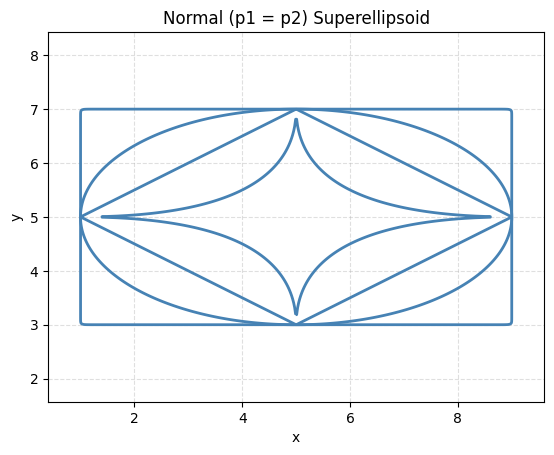

In [ ]:
# normal super ellipsoid
fig, ax = plt.subplots()

for C, U, A, P in test_ellipsoids:
    plot_superellipsoid_2d(C, U, A, P, ax=ax)

ax.set_aspect('equal')
plt.title('Normal (p1 = p2) Superellipsoid')
plt.xlabel('x')
plt.ylabel('y')
#plt.xlim(left=0,)
#plt.ylim(bottom=0)
plt.axis('equal')
plt.show()

In [34]:
# test ellipsoid 2 (variable p1, fixed p2=2)

bottom_left = np.array([5, 5])
bottom_right = np.array([15, 5])
lower_left = np.array([5, 10])
lower_right = np.array([15, 10])
upper_left = np.array([5, 15])
upper_right = np.array([15, 15])
top_left = np.array([5, 20])
top_right = np.array([15, 20])

test_ellipsoids = [
    (upper_left,
    np.array([[1, 0], [0, 1]]),
    np.array([4, 2]),
    np.array([100, 2])),

    (upper_left,
    np.array([[1, 0], [0, 1]]),
    np.array([4, 2]),
    np.array([2, 2])),

    (upper_left,
    np.array([[1, 0], [0, 1]]),
    np.array([4, 2]),
    np.array([1, 2])),

    (upper_left,
    np.array([[1, 0], [0, 1]]),
    np.array([4, 2]),
    np.array([0.5, 2])),

    (upper_right,
    np.array([[1, 0], [0, 1]]),
    np.array([4, 2]),
    np.array([2, 100])),

    (upper_right,
    np.array([[1, 0], [0, 1]]),
    np.array([4, 2]),
    np.array([2, 2])),

    (upper_right,
    np.array([[1, 0], [0, 1]]),
    np.array([4, 2]),
    np.array([2, 1])),

    (upper_right,
    np.array([[1, 0], [0, 1]]),
    np.array([4, 2]),
    np.array([2, 0.5])),

    (top_left,
    np.array([[1, 0], [0, 1]]),
    np.array([4, 2]),
    np.array([100, 100])),

    (top_left,
    np.array([[1, 0], [0, 1]]),
    np.array([4, 2]),
    np.array([100, 2])),

    (top_left,
    np.array([[1, 0], [0, 1]]),
    np.array([4, 2]),
    np.array([100, 1])),

    (top_left,
    np.array([[1, 0], [0, 1]]),
    np.array([4, 2]),
    np.array([100, 0.5])),

    (top_right,
    np.array([[1, 0], [0, 1]]),
    np.array([4, 2]),
    np.array([2, 100])),

    (top_right,
    np.array([[1, 0], [0, 1]]),
    np.array([4, 2]),
    np.array([1, 100])),

    (top_right,
    np.array([[1, 0], [0, 1]]),
    np.array([4, 2]),
    np.array([0.5, 100])),

    (top_right,
    np.array([[1, 0], [0, 1]]),
    np.array([4, 2]),
    np.array([100, 100])),

    (lower_left,
    np.array([[1, 0], [0, 1]]),
    np.array([4, 2]),
    np.array([1, 100])),

    (lower_left,
    np.array([[1, 0], [0, 1]]),
    np.array([4, 2]),
    np.array([1, 2])),

    (lower_left,
    np.array([[1, 0], [0, 1]]),
    np.array([4, 2]),
    np.array([1, 1])),

    (lower_left,
    np.array([[1, 0], [0, 1]]),
    np.array([4, 2]),
    np.array([1, 0.5])),

    (lower_right,
    np.array([[1, 0], [0, 1]]),
    np.array([4, 2]),
    np.array([2, 1])),

    (lower_right,
    np.array([[1, 0], [0, 1]]),
    np.array([4, 2]),
    np.array([1, 1])),

    (lower_right,
    np.array([[1, 0], [0, 1]]),
    np.array([4, 2]),
    np.array([0.5, 1])),

    (lower_right,
    np.array([[1, 0], [0, 1]]),
    np.array([4, 2]),
    np.array([100, 1])),

    (bottom_left,
    np.array([[1, 0], [0, 1]]),
    np.array([4, 2]),
    np.array([0.5, 100])),

    (bottom_left,
    np.array([[1, 0], [0, 1]]),
    np.array([4, 2]),
    np.array([0.5, 2])),

    (bottom_left,
    np.array([[1, 0], [0, 1]]),
    np.array([4, 2]),
    np.array([0.5, 1])),

    (bottom_left,
    np.array([[1, 0], [0, 1]]),
    np.array([4, 2]),
    np.array([0.5, 0.5])),

    (bottom_right,
    np.array([[1, 0], [0, 1]]),
    np.array([4, 2]),
    np.array([2, 0.5])),

    (bottom_right,
    np.array([[1, 0], [0, 1]]),
    np.array([4, 2]),
    np.array([1, 0.5])),

    (bottom_right,
    np.array([[1, 0], [0, 1]]),
    np.array([4, 2]),
    np.array([0.5, 0.5])),

    (bottom_right,
    np.array([[1, 0], [0, 1]]),
    np.array([4, 2]),
    np.array([100, 0.5])),

]

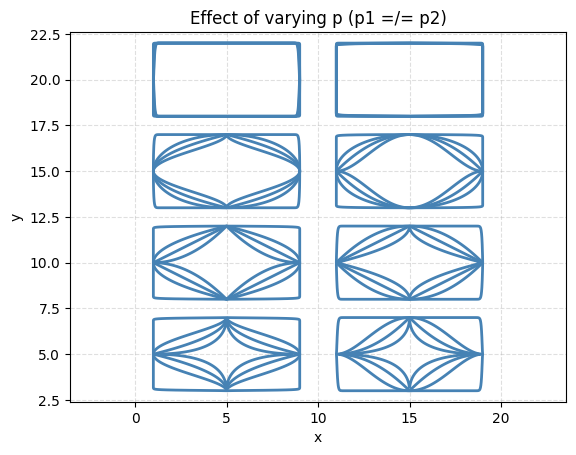

In [ ]:
# various plot of superellipsoids
fig, ax = plt.subplots()

for C, U, A, P in test_ellipsoids:
    plot_superellipsoid_2d(C, U, A, P, ax=ax)

ax.set_aspect('equal')
plt.title('Effect of varying p (p1 =/= p2)')
plt.xlabel('x')
plt.ylabel('y')
#plt.xlim(left=0,)
#plt.ylim(bottom=0)
plt.axis('equal')
plt.show()

In [42]:
# (variable p2, fixed p1=2)

test_ellipsoids = [
    (np.array([5, 5]),
    np.array([[1, 0], [0, 1]]),
    np.array([4, 2]),
    np.array([2, 100])),

    (np.array([5, 5]),
    np.array([[1, 0], [0, 1]]),
    np.array([4, 2]),
    np.array([2, 2])),

    (np.array([5, 5]),
    np.array([[1, 0], [0, 1]]),
    np.array([4, 2]),
    np.array([2, 1])),

    (np.array([5, 5]),
    np.array([[1, 0], [0, 1]]),
    np.array([4, 2]),
    np.array([2, 0.5])),

]

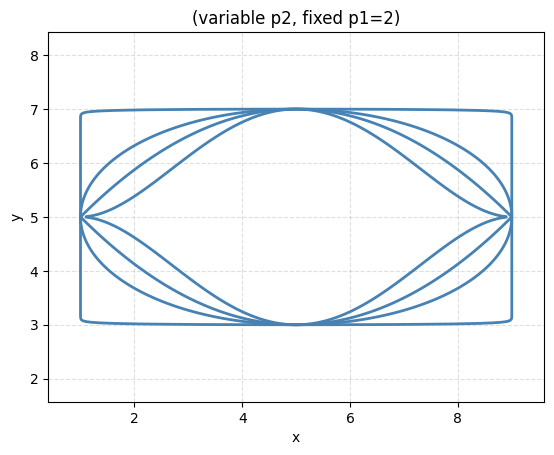

In [43]:
fig, ax = plt.subplots()

for C, U, A, P in test_ellipsoids:
    plot_superellipsoid_2d(C, U, A, P, ax=ax)

ax.set_aspect('equal')
plt.title('(variable p2, fixed p1=2)')
plt.xlabel('x')
plt.ylabel('y')
#plt.xlim(left=0,)
#plt.ylim(bottom=0)
plt.axis('equal')
plt.show()

In [44]:
#(variable p1, fixed p2=2)

test_ellipsoids = [
    (np.array([5, 5]),
    np.array([[1, 0], [0, 1]]),
    np.array([4, 2]),
    np.array([100, 2])),

    (np.array([5, 5]),
    np.array([[1, 0], [0, 1]]),
    np.array([4, 2]),
    np.array([2, 2])),

    (np.array([5, 5]),
    np.array([[1, 0], [0, 1]]),
    np.array([4, 2]),
    np.array([1, 2])),

    (np.array([5, 5]),
    np.array([[1, 0], [0, 1]]),
    np.array([4, 2]),
    np.array([0.5, 2])),

]

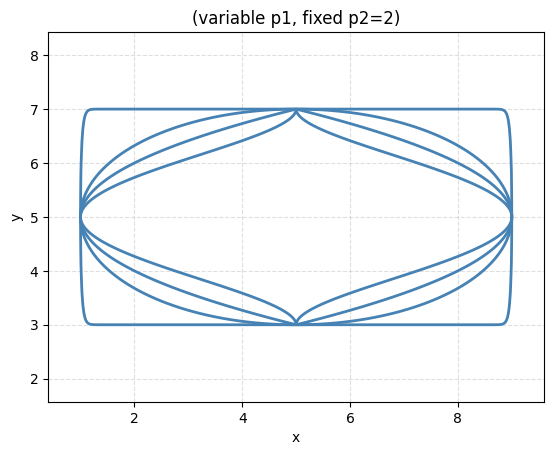

In [45]:
fig, ax = plt.subplots()

for C, U, A, P in test_ellipsoids:
    plot_superellipsoid_2d(C, U, A, P, ax=ax)

ax.set_aspect('equal')
plt.title('(variable p1, fixed p2=2)')
plt.xlabel('x')
plt.ylabel('y')
#plt.xlim(left=0,)
#plt.ylim(bottom=0)
plt.axis('equal')
plt.show()